PROPHET MODEL

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()
from sklearn.ensemble import AdaBoostRegressor 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import IsolationForest

import matplotlib.dates as mdates
import datetime as dt

In [2]:
no2_mks = pd.read_csv('data/CO_Indonesia/CO_Mks.csv')
no2_jkt = pd.read_csv('data/CO_Indonesia/CO_Jkt.csv')
no2_jpr = pd.read_csv('data/CO_Indonesia/CO_Jypr.csv')
no2_bndg = pd.read_csv('data/CO_Indonesia/CO_Bndg.csv')
no2_bks = pd.read_csv('data/CO_Indonesia/CO_Bks.csv')
no2_bgr = pd.read_csv('data/CO_Indonesia/CO_Bgr.csv')
no2_gsk = pd.read_csv('data/CO_Indonesia/CO_Grsk.csv')
no2_smrng = pd.read_csv('data/CO_Indonesia/CO_Smrng.csv')
no2_srg = pd.read_csv('data/CO_Indonesia/CO_Srng.csv')
no2_srby = pd.read_csv('data/CO_Indonesia/CO_Srby.csv')
no2_skt = pd.read_csv('data/CO_Indonesia/CO_Skt.csv')
no2_ykt = pd.read_csv('data/CO_Indonesia/CO_Ykt.csv')
no2_aceh = pd.read_csv('data/CO_Indonesia/CO_Aceh.csv')
no2_ambn = pd.read_csv('data/CO_Indonesia/CO_Ambn.csv')
no2_bali = pd.read_csv('data/CO_Indonesia/CO_Bali.csv')
no2_blkppn = pd.read_csv('data/CO_Indonesia/CO_Blkppn.csv')
no2_bngkabltng = pd.read_csv('data/CO_Indonesia/CO_BngkaBltng.csv')
no2_bngklu = pd.read_csv('data/CO_Indonesia/CO_Bngklu.csv')
no2_bnjrmsn = pd.read_csv('data/CO_Indonesia/CO_Bnjrmsn.csv')
no2_grntl = pd.read_csv('data/CO_Indonesia/CO_Grntl.csv')
no2_jmbi = pd.read_csv('data/CO_Indonesia/CO_Jmbi.csv')
no2_kendri = pd.read_csv('data/CO_Indonesia/CO_Kendri.csv')
no2_lmbk = pd.read_csv('data/CO_Indonesia/CO_Lmbk.csv')
no2_lmpng = pd.read_csv('data/CO_Indonesia/CO_Lmpng.csv')
no2_mlku = pd.read_csv('data/CO_Indonesia/CO_Maluku.csv')
no2_mmju = pd.read_csv('data/CO_Indonesia/CO_Mamuju.csv')
no2_Mankwri = pd.read_csv('data/CO_Indonesia/CO_Mankwri.csv')
no2_mdn = pd.read_csv('data/CO_Indonesia/CO_Medan.csv')
no2_mlng = pd.read_csv('data/CO_Indonesia/CO_Mlng.csv')
no2_mndo = pd.read_csv('data/CO_Indonesia/CO_Mndo.csv')
no2_mrauke = pd.read_csv('data/CO_Indonesia/CO_Mrauke.csv')
no2_nbre = pd.read_csv('data/CO_Indonesia/CO_Nbre.csv')
no2_ntt = pd.read_csv('data/CO_Indonesia/CO_NTT.csv')
no2_palu = pd.read_csv('data/CO_Indonesia/CO_Palu.csv')
no2_plmbng = pd.read_csv('data/CO_Indonesia/CO_Plmbng.csv')
no2_plngkrya = pd.read_csv('data/CO_Indonesia/CO_Plngkrya.csv')
no2_pntnk = pd.read_csv('data/CO_Indonesia/CO_Pntnk.csv')
no2_riau = pd.read_csv('data/CO_Indonesia/CO_Riau.csv')
no2_sorong= pd.read_csv('data/CO_Indonesia/CO_Sorong.csv')

In [10]:
def process_dataframe(df, suffix):
    # Rename columns
    df_renamed = df.rename(columns={
        'system:time_start': f'date_{suffix}',
        'p25': f'pm25_{suffix}',
        'Median': f'md_{suffix}',
        'IQR': f'IQR_{suffix}'
    })
    
    # Menghilangkan Data yang Tidak Penting
    df_dropped = df_renamed.drop(['Left date', 'Right date'], axis=1)
    
    # Mengisi nilai kosong dengan 0.1
    #df_filled = df_dropped.fillna(0.1)
    
    return df_dropped

# List data yang ingin didefinisikan
dfs = [
    (no2_mks, 'mks'),
    (no2_jkt, 'jkt'),
    (no2_jpr, 'jpr'),
    (no2_bndg, 'bndg'),
    (no2_bks, 'bks'),
    (no2_bgr, 'bgr'),
    (no2_gsk, 'gsk'),
    (no2_smrng, 'smrng'),
    (no2_srg, 'srg'),
    (no2_srby, 'srby'),
    (no2_skt, 'skt'),
    (no2_ykt, 'ykt'),
    (no2_aceh, 'aceh'),
    (no2_ambn, 'ambn'),
    (no2_bali, 'bali'),
    (no2_blkppn, 'blkppn'),
    (no2_bngkabltng, 'bngkabltng'),
    (no2_bngklu, 'bngklu'),
    (no2_bnjrmsn, 'bnjrmsn'),
    (no2_grntl, 'grntl'),
    (no2_jmbi, 'jmbi'),
    (no2_kendri, 'kndr'),
    (no2_lmbk, 'lmbk'),
    (no2_lmpng, 'lmpng'),
    (no2_mlku, 'mlku'),
    (no2_mmju, 'mmju'),
    (no2_Mankwri, 'mnkwri'),
    (no2_mdn, 'mdn'),
    (no2_mlng, 'mlng'),
    (no2_mndo, 'mndo'),
    (no2_mrauke, 'mrke'),
    (no2_nbre, 'nbre'),
    (no2_ntt, 'ntt'),
    (no2_palu, 'palu'),
    (no2_plmbng, 'plmbng'),
    (no2_plngkrya, 'plngkrya'),
    (no2_pntnk, 'pntnk'),
    (no2_riau, 'riau'),
    (no2_sorong, 'sorong'),
]

# Process each dataframe
processed_dfs = {suffix: process_dataframe(df, suffix) for df, suffix in dfs}

# Drop date columns
suffixes_to_drop_date = ['jkt', 'jpr', 'bndg', 'bks', 'bgr', 'gsk', 'smrng', 'srg', 'srby', 'skt', 'ykt', 
                         'aceh', 'ambn', 'bali', 'blkppn', 'bngkabltng', 'bngklu', 'bnjrmsn', 'grntl', 
                         'jmbi', 'kndr', 'lmbk', 'lmpng', 'mlku', 'mmju', 'mnkwri', 'mdn', 'mlng', 'mndo', 
                         'mrke', 'nbre', 'ntt', 'palu', 'plmbng', 'plngkrya', 'pntnk', 'riau', 'sorong']

processed_dfs_no_date = {suffix: df.drop([f'date_{suffix}'], axis=1) for suffix, df in processed_dfs.items() if suffix in suffixes_to_drop_date}

# Example: Access the processed dataframe without the date column for Jakarta
no2_jkt_4 = processed_dfs_no_date['jkt']
no2_jpr_4 = processed_dfs_no_date['jpr']
no2_bndg_4 = processed_dfs_no_date['bndg']
no2_bks_4 = processed_dfs_no_date['bks']
no2_bgr_4 = processed_dfs_no_date['bgr']
no2_gsk_4 = processed_dfs_no_date['gsk']
no2_smrng_4 = processed_dfs_no_date['smrng']
no2_srg_4 = processed_dfs_no_date['srg']
no2_srby_4 = processed_dfs_no_date['srby']
no2_skt_4 = processed_dfs_no_date['skt']
no2_ykt_4 = processed_dfs_no_date['ykt']
no2_aceh_4 = processed_dfs_no_date['aceh']
no2_ambn_4 = processed_dfs_no_date['ambn']
no2_bali_4 = processed_dfs_no_date['bali']
no2_blkppn_4 = processed_dfs_no_date['blkppn']
no2_bngkabltng_4 = processed_dfs_no_date['bngkabltng']
no2_bngklu_4 = processed_dfs_no_date['bngklu']
no2_bnjrmsn_4 = processed_dfs_no_date['bnjrmsn']
no2_grntl_4 = processed_dfs_no_date['grntl']
no2_jmbi_4 = processed_dfs_no_date['jmbi']
no2_kndr_4 = processed_dfs_no_date['kndr']
no2_lmbk_4 = processed_dfs_no_date['lmbk']
no2_lmpng_4 = processed_dfs_no_date['lmpng']
no2_mlku_4 = processed_dfs_no_date['mlku']
no2_mmju_4 = processed_dfs_no_date['mmju']
no2_mnkwri_4 = processed_dfs_no_date['mnkwri']
no2_mdn_4 = processed_dfs_no_date['mdn']
no2_mlng_4 = processed_dfs_no_date['mlng']
no2_mndo_4 = processed_dfs_no_date['mndo']
no2_mrke_4 = processed_dfs_no_date['mrke']
no2_nbre_4 = processed_dfs_no_date['nbre']
no2_ntt_4 = processed_dfs_no_date['ntt']
no2_palu_4 = processed_dfs_no_date['palu']
no2_plmbng_4 = processed_dfs_no_date['plmbng']
no2_plngkrya_4 = processed_dfs_no_date['plngkrya']
no2_pntnk_4 = processed_dfs_no_date['pntnk']
no2_riau_4 = processed_dfs_no_date['riau']
no2_sorong_4 = processed_dfs_no_date['sorong']
# Contoh akses dataframe yang diproses namun masih ada date column
no2_mks_processed = processed_dfs['mks']


KeyError: "['Left date', 'Right date'] not found in axis"

In [8]:
no2_jkt.head(10)

,Date;p25;Median;IQR
0,22/11/2018;;;
1,22/11/2018;32;34;36
2,01/12/2018;31;34;37
3,10/12/2018;3;32;35
4,19/12/2018;27;29;31
5,28/12/2018;24;25;26
6,06/01/2019;27;31;34
7,15/01/2019;3;3;31
8,24/01/2019;28;28;29
9,02/02/2019;33;34;36


In [ ]:
result_merge1 = pd.merge(no2_mks_processed, no2_jkt_4, left_index=True, right_index=True)
result_merge2 = pd.merge(result_merge1, no2_jpr_4, left_index=True, right_index=True)
result_merge3 = pd.merge(result_merge2, no2_bks_4, left_index=True, right_index=True)
result_merge4 = pd.merge(result_merge3, no2_bgr_4, left_index=True, right_index=True)
result_merge5 = pd.merge(result_merge4, no2_gsk_4, left_index=True, right_index=True)
result_merge6 = pd.merge(result_merge5, no2_srby_4, left_index=True, right_index=True)
result_merge7 = pd.merge(result_merge6, no2_smrng_4, left_index=True, right_index=True)
result_merge8 = pd.merge(result_merge7, no2_srg_4, left_index=True, right_index=True)
result_merge9 = pd.merge(result_merge8, no2_skt_4, left_index=True, right_index=True)
result_merge10 = pd.merge(result_merge9, no2_bndg_4, left_index=True, right_index=True)
result_merge11 = pd.merge(result_merge10, no2_ykt_4, left_index=True, right_index=True)
result_merge12 = pd.merge(result_merge11, no2_aceh_4, left_index=True, right_index=True)
result_merge13 = pd.merge(result_merge12, no2_ambn_4, left_index=True, right_index=True)
result_merge14 = pd.merge(result_merge13, no2_bali_4, left_index=True, right_index=True)
result_merge15 = pd.merge(result_merge14, no2_blkppn_4, left_index=True, right_index=True)
result_merge16 = pd.merge(result_merge15, no2_bngkabltng_4, left_index=True, right_index=True)
result_merge17 = pd.merge(result_merge16, no2_bngklu_4, left_index=True, right_index=True)
result_merge18 = pd.merge(result_merge17, no2_bnjrmsn_4, left_index=True, right_index=True)
result_merge19 = pd.merge(result_merge18, no2_grntl_4, left_index=True, right_index=True)
result_merge20 = pd.merge(result_merge19, no2_jmbi_4, left_index=True, right_index=True)
result_merge21 = pd.merge(result_merge20, no2_kndr_4, left_index=True, right_index=True)
result_merge22 = pd.merge(result_merge21, no2_lmbk_4, left_index=True, right_index=True)
result_merge23 = pd.merge(result_merge22, no2_lmpng_4, left_index=True, right_index=True)
result_merge24 = pd.merge(result_merge23, no2_mlku_4, left_index=True, right_index=True)
result_merge25 = pd.merge(result_merge24, no2_mmju_4, left_index=True, right_index=True)
result_merge26 = pd.merge(result_merge25, no2_mnkwri_4, left_index=True, right_index=True)
result_merge27 = pd.merge(result_merge26, no2_mdn_4, left_index=True, right_index=True)
result_merge28 = pd.merge(result_merge27, no2_mlng_4, left_index=True, right_index=True)
result_merge29 = pd.merge(result_merge28, no2_mndo_4, left_index=True, right_index=True)
result_merge30 = pd.merge(result_merge29, no2_mrke_4, left_index=True, right_index=True)
result_merge31 = pd.merge(result_merge30, no2_nbre_4, left_index=True, right_index=True)
result_merge32 = pd.merge(result_merge31, no2_ntt_4, left_index=True, right_index=True)
result_merge33 = pd.merge(result_merge32, no2_palu_4, left_index=True, right_index=True)
result_merge34 = pd.merge(result_merge33, no2_plmbng_4, left_index=True, right_index=True)
result_merge35 = pd.merge(result_merge34, no2_plngkrya_4, left_index=True, right_index=True)
result_merge36 = pd.merge(result_merge35, no2_pntnk_4, left_index=True, right_index=True)
result_merge37 = pd.merge(result_merge36, no2_riau_4, left_index=True, right_index=True)
polusi = pd.merge(result_merge37, no2_sorong_4, left_index=True, right_index=True)
polusi.head(10).T
polusi.to_csv('polusi5_1.csv')

In [38]:
polusi = pd.read_csv('polusi5_1.csv')
polusi.isnull().sum()

Unnamed: 0     0
date_mks       0
pm25_mks       2
md_mks         2
IQR_mks        2
              ..
md_riau        2
IQR_riau       2
pm25_sorong    2
md_sorong      2
IQR_sorong     2
Length: 119, dtype: int64

In [39]:
def rename_column(df_in, cn1, cn2, cn3, cn4):
    df_out = df_in.rename(columns={'system:time_start': cn1, 'p25': cn2, 'Median': cn3, 'IQR': cn4})
    df_out = df_out.drop(['Left date', 'Right date'],axis=1)
    return df_out 

no2_mks_3 = rename_column(no2_mks, 'date_mks', 'pm25_mks', 'md_mks', 'IQR_mks')


In [40]:
DATA_INFO= pd.to_datetime(polusi['date_mks'])
date_time=pd.concat([DATA_INFO], axis=1)

In [41]:
polutan = ['IQR_mks', 'IQR_jkt', 'IQR_jpr', 'IQR_bndg', 'IQR_bks', 'IQR_bgr', 'IQR_gsk', 'IQR_smrng', 'IQR_srg', 'IQR_srby', 'IQR_skt', 'IQR_ykt', 'IQR_aceh', 'IQR_ambn', 'IQR_bali', 'IQR_blkppn', 'IQR_bngkabltng', 'IQR_bngklu', 'IQR_bnjrms', 'IQR_grntl', 'IQR_jmbi', 'IQR_kndr', 'IQR_lmbk', 'IQR_lmpng', 'IQR_mlku', 'IQR_mmju', 'IQR_mnkwri', 'IQR_mdn', 'IQR_mlng', 'IQR_mndo', 'IQR_mrke', 'IQR_nbre', 'IQR_ntt', 'IQR_palu', 'IQR_plmbng', 'IQR_plngkrya', 'IQR_pntnk', 'IQR_riau', 'IQR_sorong']

In [ ]:
polutan = ['IQR_mks', 'IQR_jkt', 'IQR_jpr', 'IQR_bndg', 'IQR_bks', 'IQR_bgr', 'IQR_gsk', 'IQR_smrng', 'IQR_srg', 'IQR_srby', 'IQR_skt', 'IQR_ykt', 'IQR_aceh', 'IQR_ambn', 'IQR_bali', 'IQR_blkppn', 'IQR_bngkabltng', 'IQR_bngklu', 'IQR_bnjrms', 'IQR_grntl', 'IQR_jmbi', 'IQR_kndr', 'IQR_lmbk', 'IQR_lmpng', 'IQR_mlku', 'IQR_mmju', 'IQR_mnkwri', 'IQR_mdn', 'IQR_mlng', 'IQR_mndo', 'IQR_mrke', 'IQR_nbre', 'IQR_ntt', 'IQR_palu', 'IQR_plmbng', 'IQR_plngkrya', 'IQR_pntnk', 'IQR_riau', 'IQR_sorong']
polusi.set_index('date_mks',inplace=True)

axes = polusi[polutan].plot(marker='.', alpha=0.5, linestyle='None', figsize=(16, 20), subplots=True)
for ax in axes:
    
    ax.set_xlabel('Years')
    ax.set_ylabel('ug / m3')

KeyError: "['IQR_bnjrms'] not in index"

In [42]:
date_time ['ds'] = date_time['date_mks'].astype(str) 

In [43]:
data= pd.DataFrame()
data['ds'] = pd.to_datetime(date_time ['ds'].astype(str))
data['y'] = polusi['IQR_mks'].values

##digukan jika ada data yang degan tanda ptik koma (,) dan digantikan dengan titik (.)
#data['y'] = data['y'].str.replace(',', '').astype(float)

## Menghapus nilai-nilai tertentu dari kolom 'y'
data = data[~data['y'].isin([0.061, 0.053, 0.054])]

#Menghilangkan data NaN
data = data.dropna() 
data.head()

,ds,y
1,2018-11-22,0.032
2,2018-12-01,0.029
3,2018-12-10,0.031
4,2018-12-19,0.028
5,2018-12-28,0.026


In [44]:
# Membuat DataFrame
df = pd.DataFrame(data)

# Menghitung rata-rata dari data setelah baris pertama
mean_value = df.loc[1:, 'y'].mean()
#mean_value = df.loc[10:, 'y'].mean()

# Mengganti nilai baris pertama dengan nilai rata-rata
df.at[1, 'y'] = mean_value
df.at[9, 'y'] = mean_value

df.head()

,ds,y
1,2018-11-22,0.028265
2,2018-12-01,0.029000
3,2018-12-10,0.031000
4,2018-12-19,0.028000
5,2018-12-28,0.026000


In [45]:
# Membuat DataFrame
df = pd.DataFrame(data)

# Membuat dan melatih model IsolationForest
model = IsolationForest(contamination=0.1)  # Set contamination sesuai dengan ekspektasi proporsi outlier
df['y'] = df['y'].values.reshape(-1, 1)  # Mengubah format data untuk kompatibilitas dengan model
model.fit(df[['y']])

# Memprediksi outlier
df['anomaly'] = model.predict(df[['y']])

# Identifikasi outlier (1 = inlier, -1 = outlier)
outliers = df[df['anomaly'] == -1]

# Menghitung rata-rata dari nilai non-outlier
mean_value = df[df['anomaly'] == 1]['y'].mean()

# Mengganti nilai outlier dengan rata-rata
df.loc[df['anomaly'] == -1, 'y'] = mean_value

# Menghapus kolom tambahan
df = df.drop(columns=['anomaly'])
df.head(10)

,ds,y
1,2018-11-22,0.028265
2,2018-12-01,0.029000
3,2018-12-10,0.031000
4,2018-12-19,0.028000
5,2018-12-28,0.026000
6,2019-01-06,0.029000
7,2019-01-15,0.027000
8,2019-01-24,0.030000
9,2019-02-02,0.028265
10,2019-02-11,0.031000


In [46]:
from prophet import Prophet
model = Prophet()
model.fit(data)


21:59:13 - cmdstanpy - INFO - Chain [1] start processing
21:59:14 - cmdstanpy - INFO - Chain [1] done processing


In [47]:
future = model.make_future_dataframe(periods=10000, freq='h')
future.tail()

,ds
10225,2025-09-03 12:00:00
10226,2025-09-03 13:00:00
10227,2025-09-03 14:00:00
10228,2025-09-03 15:00:00
10229,2025-09-03 16:00:00


In [48]:
forecast = model.predict(future)
forecast [['ds', 'yhat','yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
10225,2025-09-03 12:00:00,0.032351,0.029788,0.035084
10226,2025-09-03 13:00:00,0.032361,0.029804,0.034993
10227,2025-09-03 14:00:00,0.032371,0.029687,0.035315
10228,2025-09-03 15:00:00,0.032380,0.029595,0.035123
10229,2025-09-03 16:00:00,0.032390,0.029559,0.035025


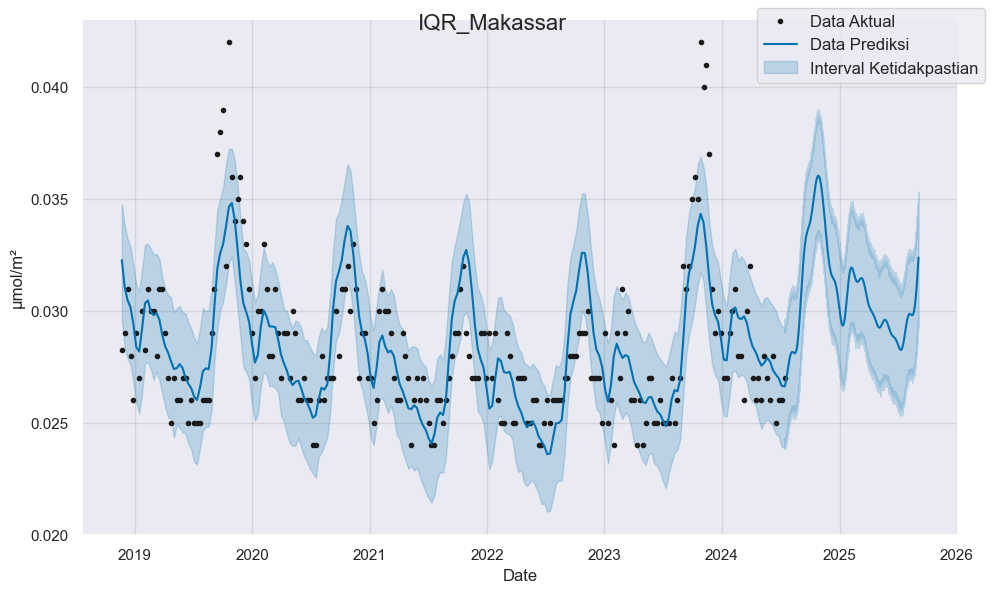

In [49]:
fig1 = model.plot(forecast, xlabel='Date', ylabel='µmol/m²')
fig1.suptitle('IQR_Makassar', fontsize=16) 

#membuat legenda
fig1.legend(['Data Aktual','Data Prediksi','Interval Ketidakpastian'], loc='upper right', fontsize = 12)


In [54]:
df.head(300)

,ds,y
1,2018-11-22,0.028265
2,2018-12-01,0.029000
3,2018-12-10,0.031000
4,2018-12-19,0.028000
5,2018-12-28,0.026000
...,...,...
227,2024-06-08,0.028000
228,2024-06-17,0.025000
229,2024-06-26,0.026000
230,2024-07-05,0.026000


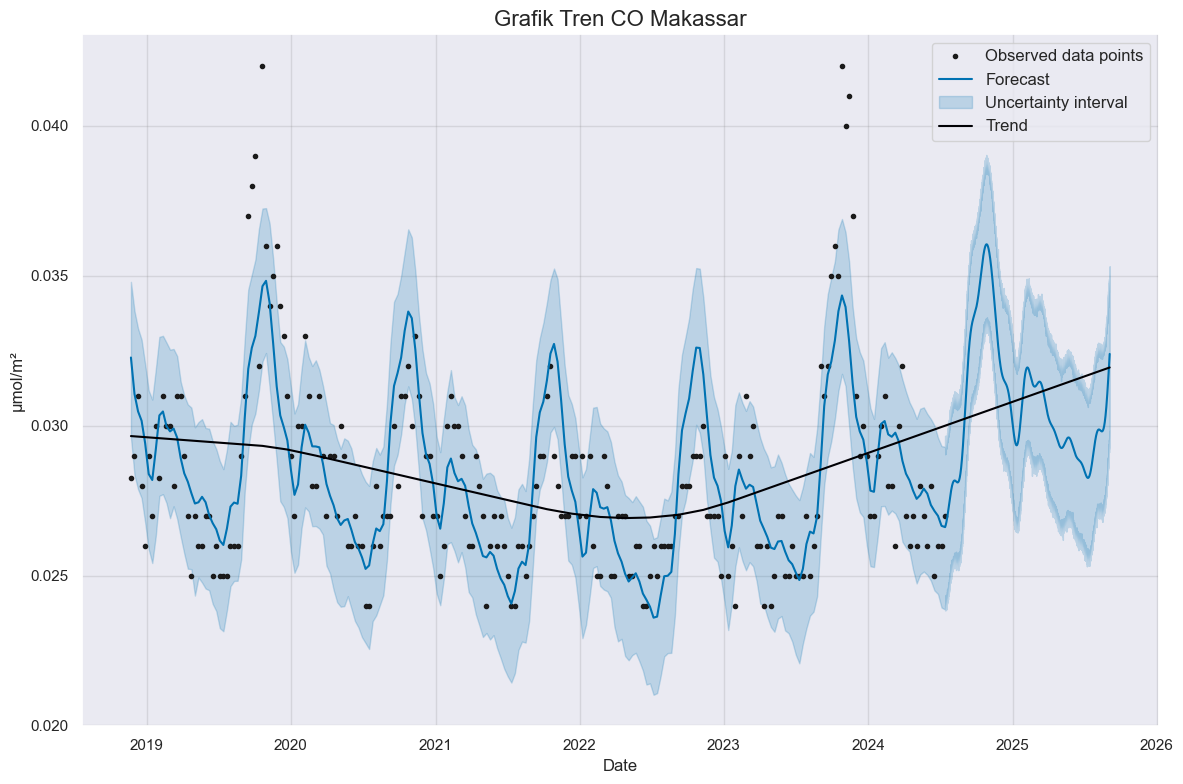

In [ ]:
# Membuat figure dan axes
fig, ax = plt.subplots(figsize=(12, 8))

# Plot data utama (forecast)
model.plot(forecast, ax=ax)

# Ekstrak komponen dari forecast
trend = forecast[['ds', 'trend']]

# Tambahkan trend dan seasonal secara manual
ax.plot(trend['ds'], trend['trend'], linestyle='-', color='#000004', label='Trend')

# Tambahkan judul dan legenda
ax.set_title('Grafik Tren CO Makassar', fontsize=16)
ax.legend(loc='upper right', fontsize=12)
plt.xlabel('Date')
plt.ylabel('µmol/m²')

#men-highlight hasil prediksi
t = mdates.drange(dt.datetime(2018, 11, 22), dt.datetime(2024, 7, 14),
                  dt.timedelta(hours=2))
y = np.sin(t)

plt.plot(range(10))
plt.axvspan(*mdates.datestr2num(['7/14/2024', '10/1/2025']), color='red', alpha=0.5)
fig.autofmt_xdate()

# Menampilkan hasil
plt.tight_layout()
plt.show()

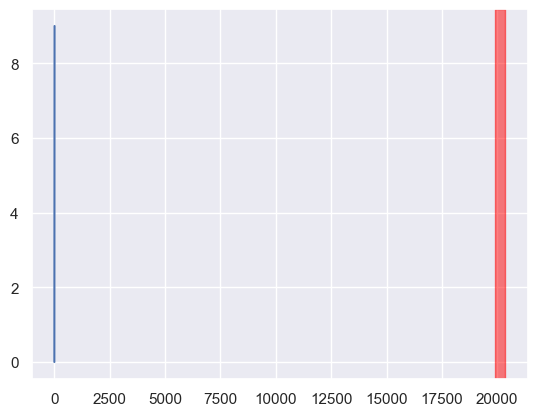

In [57]:
#men-highlight hasil prediksi
t = mdates.drange(dt.datetime(2018, 11, 22), dt.datetime(2024, 7, 14),
                  dt.timedelta(hours=2))
y = np.sin(t)

plt.plot(range(10))
plt.axvspan(*mdates.datestr2num(['7/14/2024', '10/1/2025']), color='red', alpha=0.5)
fig.autofmt_xdate()


Text(0.5, 0.98, 'IQR_Makassar')

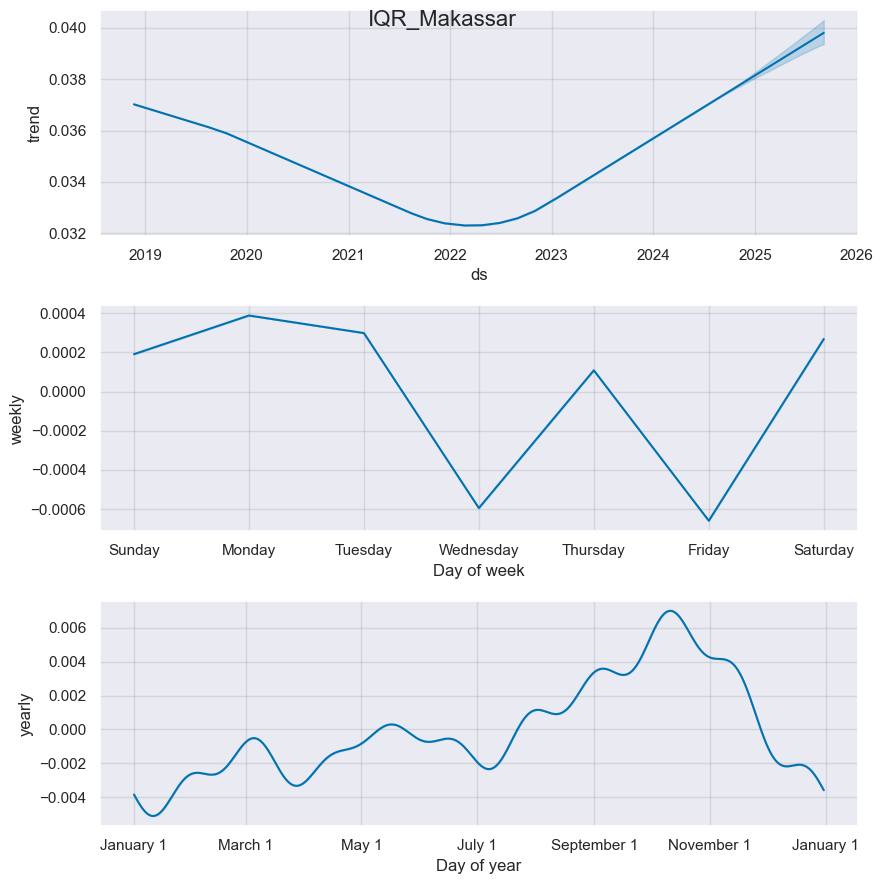

In [ ]:
fig2 = model.plot_components(forecast)
fig2.suptitle('IQR_Makassar', fontsize=16)

In [ ]:
from prophet.plot import plot_plotly, plot_components_plotly

fig3 = plot_plotly(model, forecast)
fig3.update_layout(title='IQR_Makassar', title_font_size=16,  title_x=0.5)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': 'black', 'size': 4},
              'mode': 'markers',
              'name': 'Actual',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 11, 22, 0, 0),
                          datetime.datetime(2018, 12, 1, 0, 0),
                          datetime.datetime(2018, 12, 10, 0, 0), ...,
                          datetime.datetime(2024, 6, 17, 0, 0),
                          datetime.datetime(2024, 6, 26, 0, 0),
                          datetime.datetime(2024, 7, 14, 0, 0)], dtype=object),
              'y': array([0.036, 0.037, 0.035, ..., 0.03 , 0.034, 0.035])},
             {'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 11, 22, 0, 0),
                          datetime.datetime(2018, 12, 1, 0, 0),
                          datetime.datetime(2018, 12, 10, 0, 0), ...,
                          datetime.datetime(2025, 9, 3, 14, 0),
                          datetime.datetime(2025, 9, 3, 15, 0),
                          datetime.datetime(2025, 9, 3, 16, 0)], dtype=object),
              'y': array([0.03487296, 0.03254762, 0.03118415, ..., 0.03910858, 0.03928356,
                          0.03939134])},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'line': {'color': '#0072B2', 'width': 2},
              'mode': 'lines',
              'name': 'Predicted',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 11, 22, 0, 0),
                          datetime.datetime(2018, 12, 1, 0, 0),
                          datetime.datetime(2018, 12, 10, 0, 0), ...,
                          datetime.datetime(2025, 9, 3, 14, 0),
                          datetime.datetime(2025, 9, 3, 15, 0),
                          datetime.datetime(2025, 9, 3, 16, 0)], dtype=object),
              'y': array([0.03911561, 0.03639931, 0.03519616, ..., 0.04328274, 0.04332092,
                          0.04335595])},
             {'fill': 'tonexty',
              'fillcolor': 'rgba(0, 114, 178, 0.2)',
              'hoverinfo': 'skip',
              'line': {'width': 0},
              'mode': 'lines',
              'type': 'scatter',
              'x': array([datetime.datetime(2018, 11, 22, 0, 0),
                          datetime.datetime(2018, 12, 1, 0, 0),
                          datetime.datetime(2018, 12, 10, 0, 0), ...,
                          datetime.datetime(2025, 9, 3, 14, 0),
                          datetime.datetime(2025, 9, 3, 15, 0),
                          datetime.datetime(2025, 9, 3, 16, 0)], dtype=object),
              'y': array([0.04322292, 0.04077401, 0.03923906, ..., 0.04730086, 0.04750271,
                          0.047383  ])}],
    'layout': {'height': 600,
               'showlegend': False,
               'template': '...',
               'title': {'font': {'size': 16}, 'text': 'IQR_Makassar', 'x': 0.5},
               'width': 900,
               'xaxis': {'rangeselector': {'buttons': [{'count': 7, 'label': '1w', 'step': 'day', 'stepmode': 'backward'},
                                                       {'count': 1,
                                                        'label': '1m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 6,
                                                        'label': '6m',
                                                        'step': 'month',
                                                        'stepmode': 'backward'},
                                                       {'count': 1, 'label': '1y', 'step': 'year', 'stepmode': 'backward'},
                                                       {'step': 'all'}]},
                      

In [ ]:
jkt = 0.046, 0.047,0.048, 0.049, 0.049, 0.05, 0.47, 0.048, 0.049

In [ ]:
# Ekstrak nilai aktual dari data
y_true = data['y'].values

# Membuat dataframe masa depan yang mencakup semua tanggal dalam data asli
future = pd.DataFrame(date_time['ds'])

# Membuat prediksi
forecast = model.predict(future)

# Ekstrak nilai prediksi untuk periode yang sesuai dengan nilai aktual
# Menggunakan `merge` untuk memastikan kita hanya mengambil tanggal yang sesuai
merged = pd.concat([forecast['ds'], forecast['yhat']])

# Pastikan panjang y_true dan y_pred sama
y_true = data['y'].values
y_pred = forecast['yhat'].values

assert len(y_true) == len(y_pred), f"Length of y_true ({len(y_true)}) and y_pred ({len(y_pred)}) do not match."

#Disebabkan ada data NaN maka menggunakan fungsi "mask" untuk menghilangkan data tersebut.
mask = ~np.isnan(y_true) & ~np.isnan(y_pred)

# Hitung RMSE
rmse = np.sqrt(mean_squared_error(y_true [mask], y_pred[mask]))
print(f"RMSE: {rmse}")

# Hitung R²
r2 = r2_score(y_true[mask], y_pred[mask])
print(f"R²: {r2}")

#MAE
mae = mean_absolute_error(y_true[mask], y_pred[mask])
print(f"MAE: {mae}")

fig1 = model.plot(forecast)
fig1.suptitle('IQR_Jakarta', fontsize=16)

# Tambahkan nilai RMSE dan R² ke plot
plt.figtext(0.15, 0.85, f'RMSE: {rmse:.2f}', fontsize=12)
plt.figtext(0.15, 0.80, f'R²: {r2:.2f}', fontsize=12)

# Tampilkan plot
plt.show()


AssertionError: Length of y_true (230) and y_pred (232) do not match.

In [ ]:
metric_df = forecast.set_index('ds')[['yhat']].join(data.set_index('ds').y).reset_index()
metric_df.tail()

,ds,yhat,y
10222,2025-09-03 12:00:00,0.043187,NaN
10223,2025-09-03 13:00:00,0.043227,NaN
10224,2025-09-03 14:00:00,0.043266,NaN
10225,2025-09-03 15:00:00,0.043302,NaN
10226,2025-09-03 16:00:00,0.043336,NaN


In [ ]:
metric_df.dropna(inplace=True)
metric_df.tail()

,ds,yhat,y
222,2024-05-30,0.036287,0.034
223,2024-06-08,0.036337,0.036
224,2024-06-17,0.036701,0.030
225,2024-06-26,0.035031,0.034
226,2024-07-14,0.035538,0.035


In [ ]:
r2 = r2_score(metric_df.y, metric_df.yhat)
mse = mean_squared_error(metric_df.y,metric_df.yhat)
rmse = np.sqrt(mse)
mae = mean_absolute_error(metric_df.y, metric_df.yhat)

print(f"RMSE: {rmse}")
print(f"MSE: {mse}")
print(f"R2: {r2}")
print(f"MAE: {mae}")

RMSE: 0.0032126125683198375
MSE: 1.0320879514126582e-05
R2: 0.5030864016460552
MAE: 0.002469091887280411
